In [1]:
pip install scipy

In [11]:
pip install pillow

Note: you may need to restart the kernel to use updated packages.


In [1]:
import qutip as qp
import numpy as np

In [3]:
import operators

In [5]:
g = 3
N= 8
w = 3
m = 0

mu_list = np.linspace(0, (g*1.4), 50)
T_list = np.linspace(0.1, (g*2.5), 50)

In [7]:
chiral_mat = []
for mu in (mu_list):
    chiral_list = []
    H = operators.construct_Hamiltonian(g, w, N, mu, m)
    for T in (T_list):
        rho = operators.get_exact_Gibbs_state(H, T, g)
        chiral = operators.est_chiral(N,rho,(1/(2*w)))
        chiral_list.append(chiral)
    chiral_mat.append(np.copy(chiral_list))

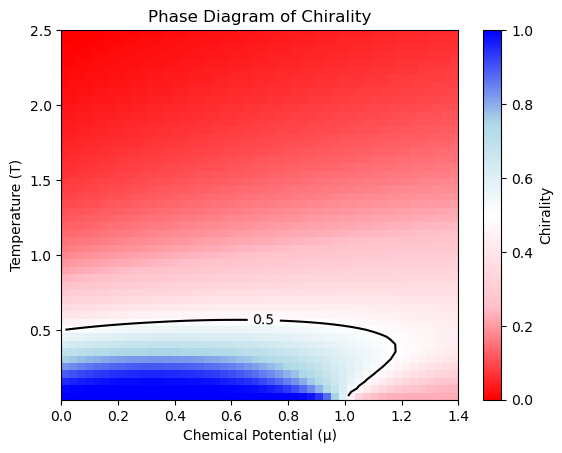

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# 假设mu_list和T_list已经定义，并且与chiral_mat的对应轴长度相同

# 将chiral_mat转换为numpy数组以便于处理
chiral_mat = np.transpose(np.abs(np.array(chiral_mat)))

min_val = np.min(chiral_mat)
max_val = np.max(chiral_mat)

# 防止最大值和最小值相同的情况，避免除以零
if max_val - min_val == 0:
    chiral_mat = np.zeros_like(chiral_mat)
else:
    # 进行最小-最大缩放
    chiral_mat = (chiral_mat - min_val) / (max_val - min_val)

# 创建自定义颜色图，0.5前后颜色不同且渐变
colors = ['red', 'pink', 'white', 'lightblue', 'blue']
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', colors)

# 创建图形和轴
fig, ax = plt.subplots()

# 创建热图
cax = ax.imshow(chiral_mat, aspect='auto', cmap=cmap, origin='lower', extent=[min(mu_list/g), max(mu_list/g), min(T_list/g), max(T_list/g)])

# 添加颜色条
cbar = fig.colorbar(cax)
cbar.set_label('Chirality')

# 设置轴标签
ax.set_xlabel('Chemical Potential (μ)')
ax.set_ylabel('Temperature (T)')

# 添加0.5等值线
contour = ax.contour(chiral_mat, levels=[0.5], colors='black', origin='lower', extent=[min(mu_list/g), max(mu_list/g), min(T_list/g), max(T_list/g)])
ax.clabel(contour, inline=1, fontsize=10)

# 设置标题
ax.set_title('Phase Diagram of Chirality')

# 显示图形
plt.show()


In [11]:
chiral_mat_theo = []
for mu in (mu_list):
    chiral_list_theo = []
    for T in (T_list):
        chiral = operators.theo_chiral(T, mu, g)
        chiral_list_theo.append(chiral)
    chiral_mat_theo.append(np.copy(chiral_list_theo))

C:\Users\robwa\operators.py:81: RuntimeWarning: overflow encountered in exp
  fx = 1/(1 - np.exp(a*np.cosh(x)))
C:\Users\robwa\operators.py:81: RuntimeWarning: overflow encountered in cosh
  fx = 1/(1 - np.exp(a*np.cosh(x)))


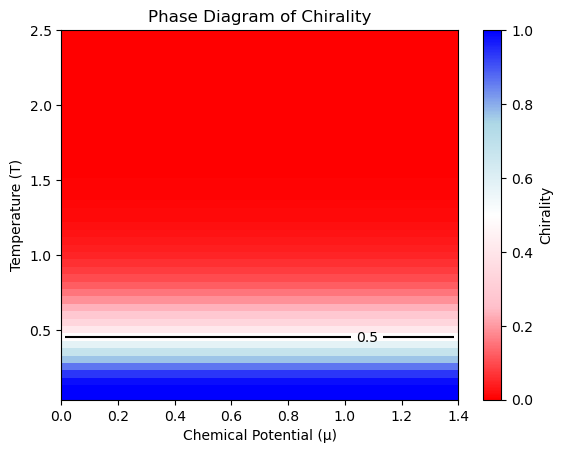

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# 假设mu_list和T_list已经定义，并且与chiral_mat的对应轴长度相同

# 将chiral_mat转换为numpy数组以便于处理
chiral_mat_theo = np.transpose(np.abs(np.array(chiral_mat_theo)))

min_val = np.min(chiral_mat_theo)
max_val = np.max(chiral_mat_theo)

# 防止最大值和最小值相同的情况，避免除以零
if max_val - min_val == 0:
    chiral_mat_theo = np.zeros_like(chiral_mat_theo)
else:
    # 进行最小-最大缩放
    chiral_mat_theo = (chiral_mat_theo - min_val) / (max_val - min_val)

# 创建自定义颜色图，0.5前后颜色不同且渐变
colors = ['red', 'pink', 'white', 'lightblue', 'blue']
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', colors)

# 创建图形和轴
fig, ax = plt.subplots()

# 创建热图
cax = ax.imshow(chiral_mat_theo, aspect='auto', cmap=cmap, origin='lower', extent=[min(mu_list/g), max(mu_list/g), min(T_list/g), max(T_list/g)])

# 添加颜色条
cbar = fig.colorbar(cax)
cbar.set_label('Chirality')

# 设置轴标签
ax.set_xlabel('Chemical Potential (μ)')
ax.set_ylabel('Temperature (T)')

# 添加0.5等值线
contour = ax.contour(chiral_mat_theo, levels=[0.5], colors='black', origin='lower', extent=[min(mu_list/g), max(mu_list/g), min(T_list/g), max(T_list/g)])
ax.clabel(contour, inline=1, fontsize=10)

# 设置标题
ax.set_title('Phase Diagram of Chirality')

# 显示图形
plt.show()
